In [296]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression ,Lasso, Ridge
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sns

In [297]:
cost_matrix=np.array([[0,5],[1,0]])
print(cost_matrix)

nan=np.genfromtxt('D:\\ISE_LAB\\ML-Newbie-Training\\Week 2\\Data\\german.data-numeric')
data=pd.DataFrame(data=nan,columns=['A'+ str(i) for i in range (1,25)]+['Label'])
data['Label']=data['Label'].replace(2,0)
print(data.head())
print(data.info())
print(data.isnull().sum())
print(data.describe())

[[0 5]
 [1 0]]
    A1    A2   A3    A4   A5   A6   A7   A8   A9   A10  ...  A16  A17  A18  \
0  1.0   6.0  4.0  12.0  5.0  5.0  3.0  4.0  1.0  67.0  ...  0.0  0.0  1.0   
1  2.0  48.0  2.0  60.0  1.0  3.0  2.0  2.0  1.0  22.0  ...  0.0  0.0  1.0   
2  4.0  12.0  4.0  21.0  1.0  4.0  3.0  3.0  1.0  49.0  ...  0.0  0.0  1.0   
3  1.0  42.0  2.0  79.0  1.0  4.0  3.0  4.0  2.0  45.0  ...  0.0  0.0  0.0   
4  1.0  24.0  3.0  49.0  1.0  3.0  3.0  4.0  4.0  53.0  ...  1.0  0.0  1.0   

   A19  A20  A21  A22  A23  A24  Label  
0  0.0  0.0  1.0  0.0  0.0  1.0    1.0  
1  0.0  0.0  1.0  0.0  0.0  1.0    0.0  
2  0.0  0.0  1.0  0.0  1.0  0.0    1.0  
3  0.0  0.0  0.0  0.0  0.0  1.0    1.0  
4  0.0  0.0  0.0  0.0  0.0  1.0    0.0  

[5 rows x 25 columns]
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      1000 non-null   float64
 1   A2      1000 non-null   float64
 2  

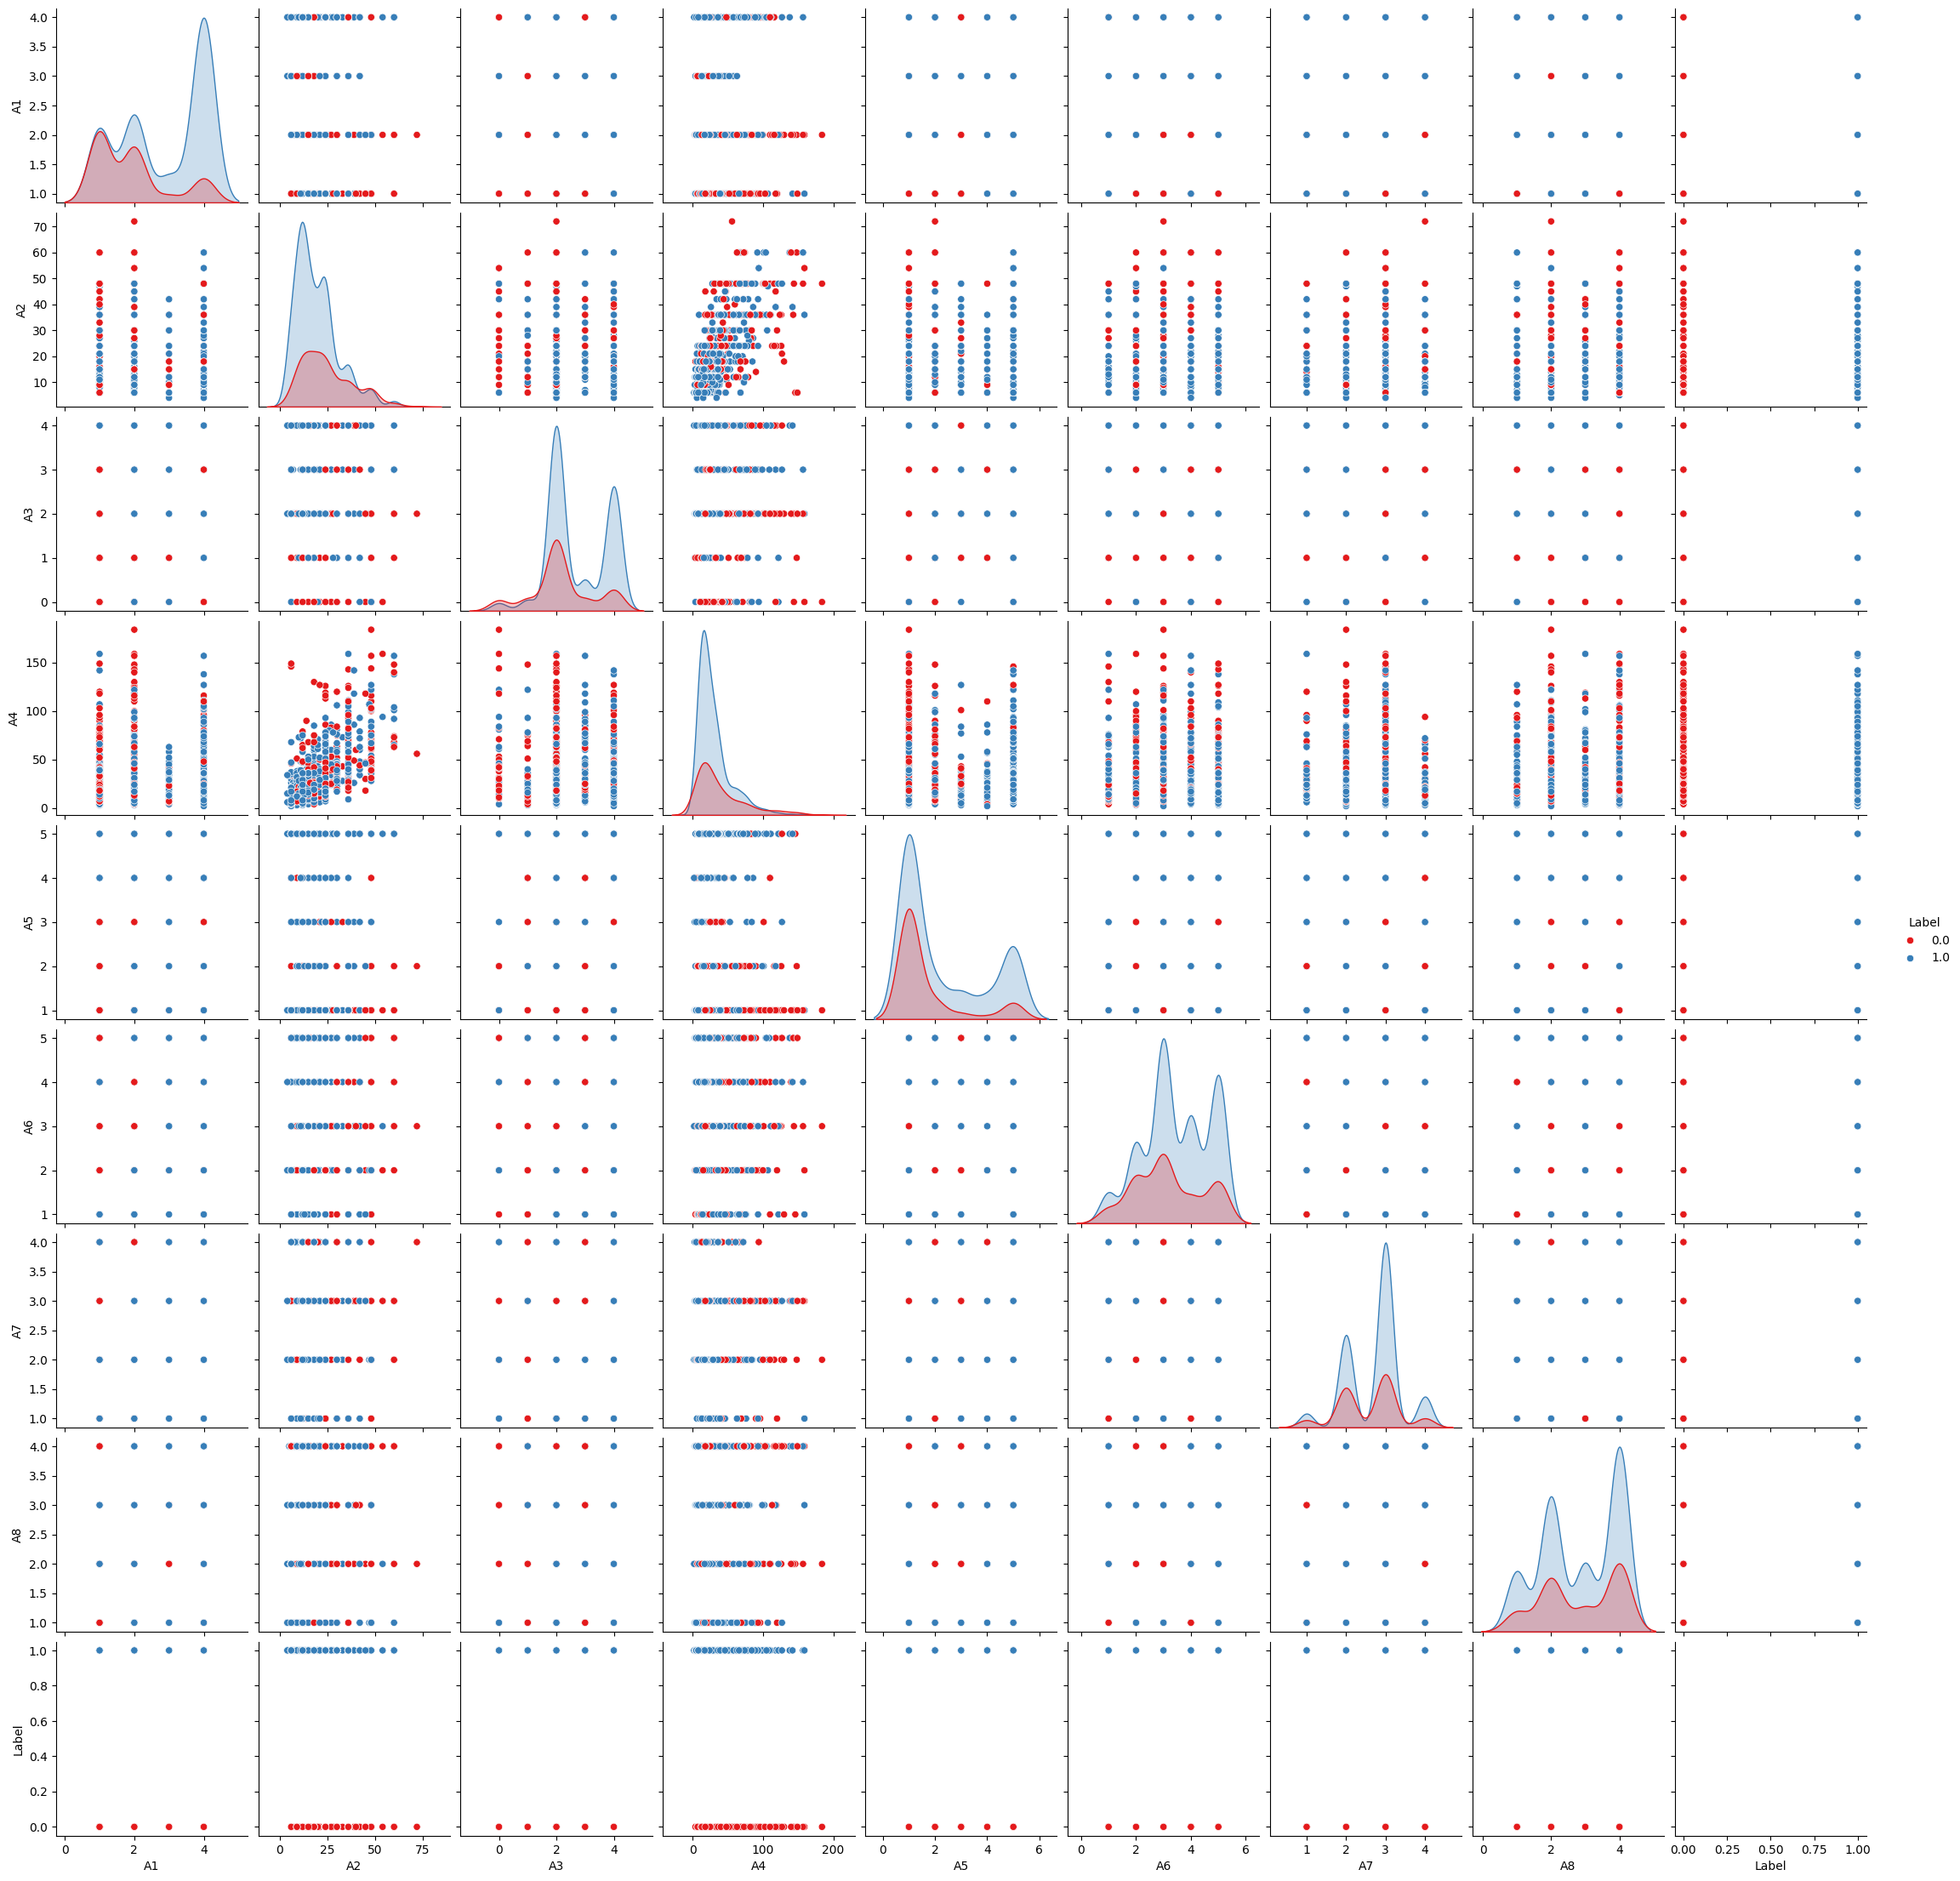

In [298]:
sns.pairplot(data,hue='Label',vars=['A'+ str(i) for i in range(1,9)]+['Label'],palette='Set1')
plt.show()

<Axes: xlabel='Label', ylabel='count'>

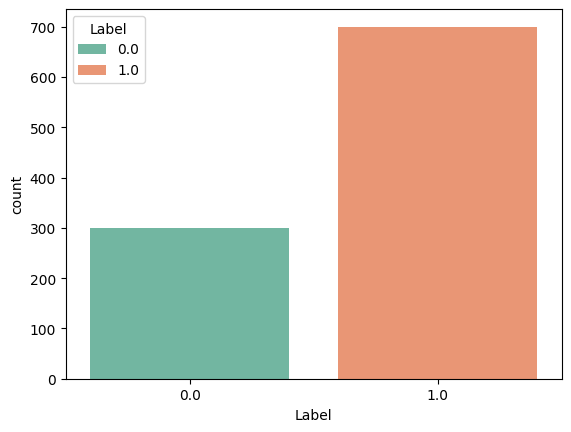

In [299]:
sns.countplot(data=data,x=data['Label'],hue='Label',palette='Set2')

In [300]:
def MM_Scaling(x):
    min=np.min(x,axis=0)
    max=np.max(x,axis=0)
    x_sl=(x-min)/(max-min)
    return x_sl

col_scl=['A'+ str(i) for i in range(1,11)]

from sklearn.model_selection import train_test_split as ttp

x=data.drop('Label',axis=1)
y=data['Label']
x_train,x_test,y_train,y_test=ttp(x,y,test_size=0.2,random_state=42)

262
[[124  17]
 [ 49  10]]
0.67 0.37037037037037035 0.1694915254237288


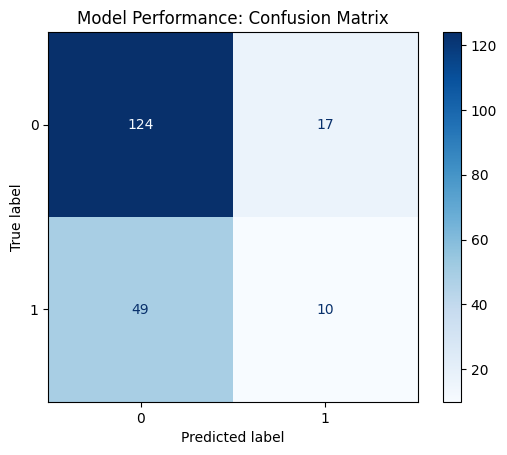

In [301]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,ConfusionMatrixDisplay

def cost(test,pred):
    total=0
    for t,p in zip(test,pred):
        total+= cost_matrix[int(t),int(p)]        
    return total


model=KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
model.fit(x_train,y_train)
y_pred= model.predict(x_test)

print(cost(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred,labels=[1,0])
print(cm)
ac=accuracy_score(y_test,y_pred)
pc=precision_score(y_test,y_pred,pos_label=0)
rc=recall_score(y_test,y_pred,pos_label=0)
print(ac,pc,rc)

# Plotting with a nice color map
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Model Performance: Confusion Matrix')
plt.show()

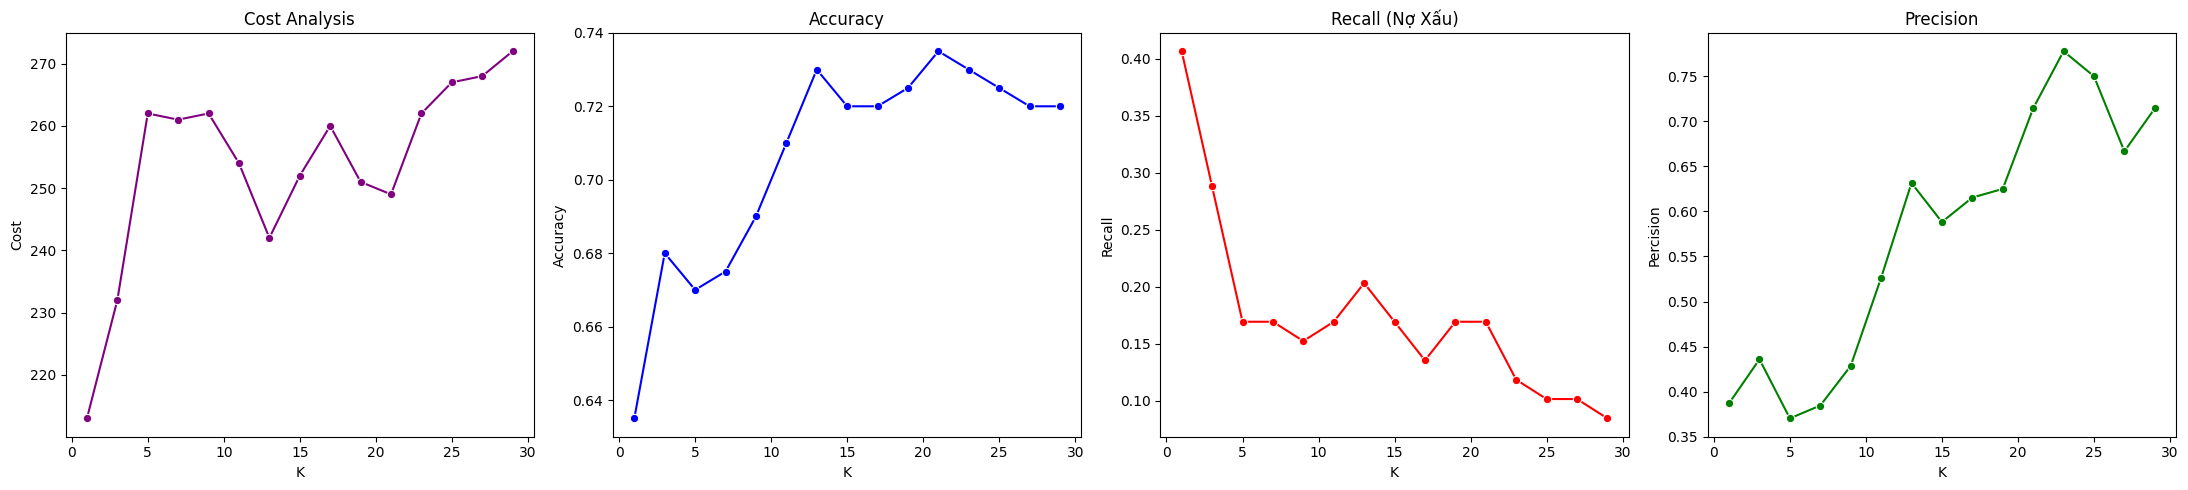

Max_Recall 0.41
Min_Cost 213


In [302]:
acc=[]
pcc=[]
rcc=[]
costt=[]

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='minkowski',p=2)
    model.fit(x_train,y_train)
    y_pred= model.predict(x_test)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())

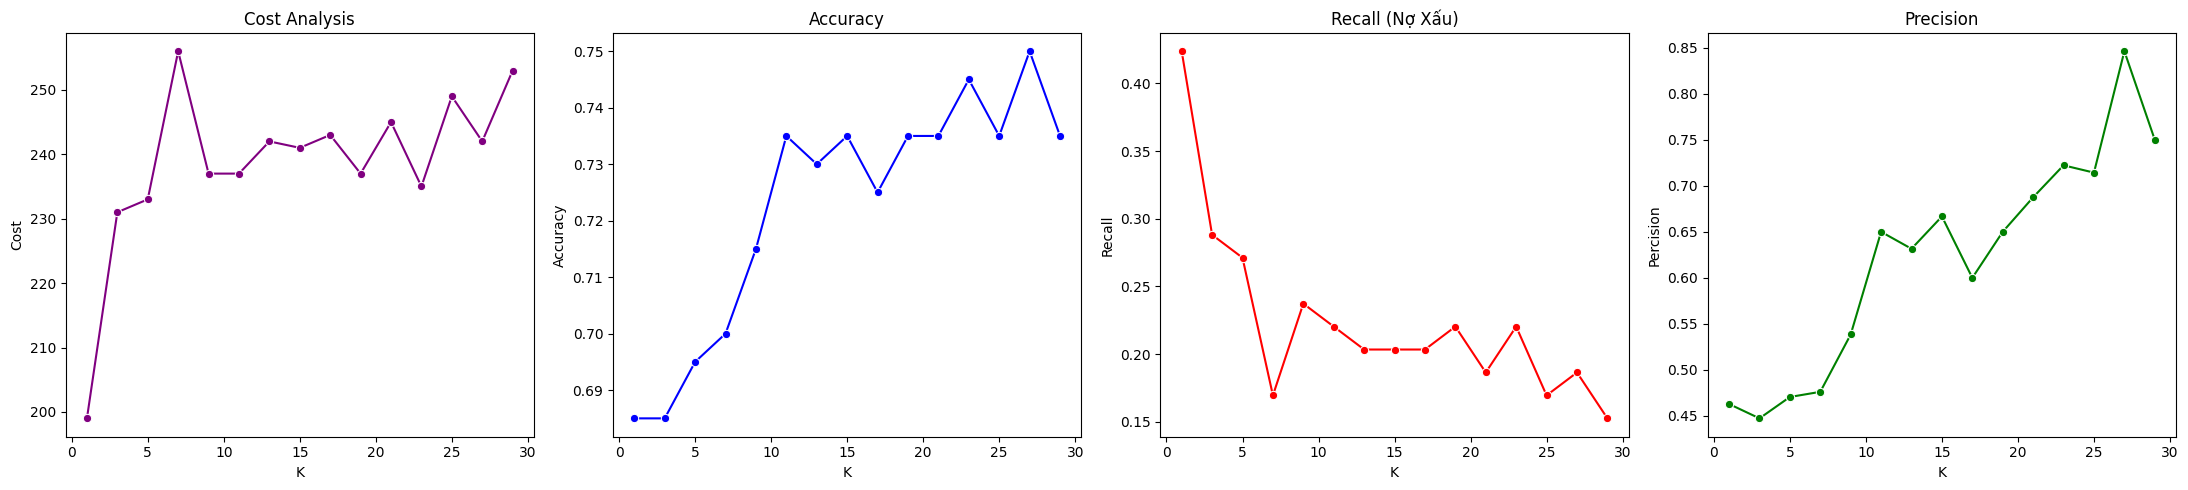

Max_Recall 0.42
Min_Cost 199


In [303]:
acc=[]
pcc=[]
rcc=[]
costt=[]

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='manhattan',p=2)
    model.fit(x_train,y_train)
    y_pred= model.predict(x_test)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())


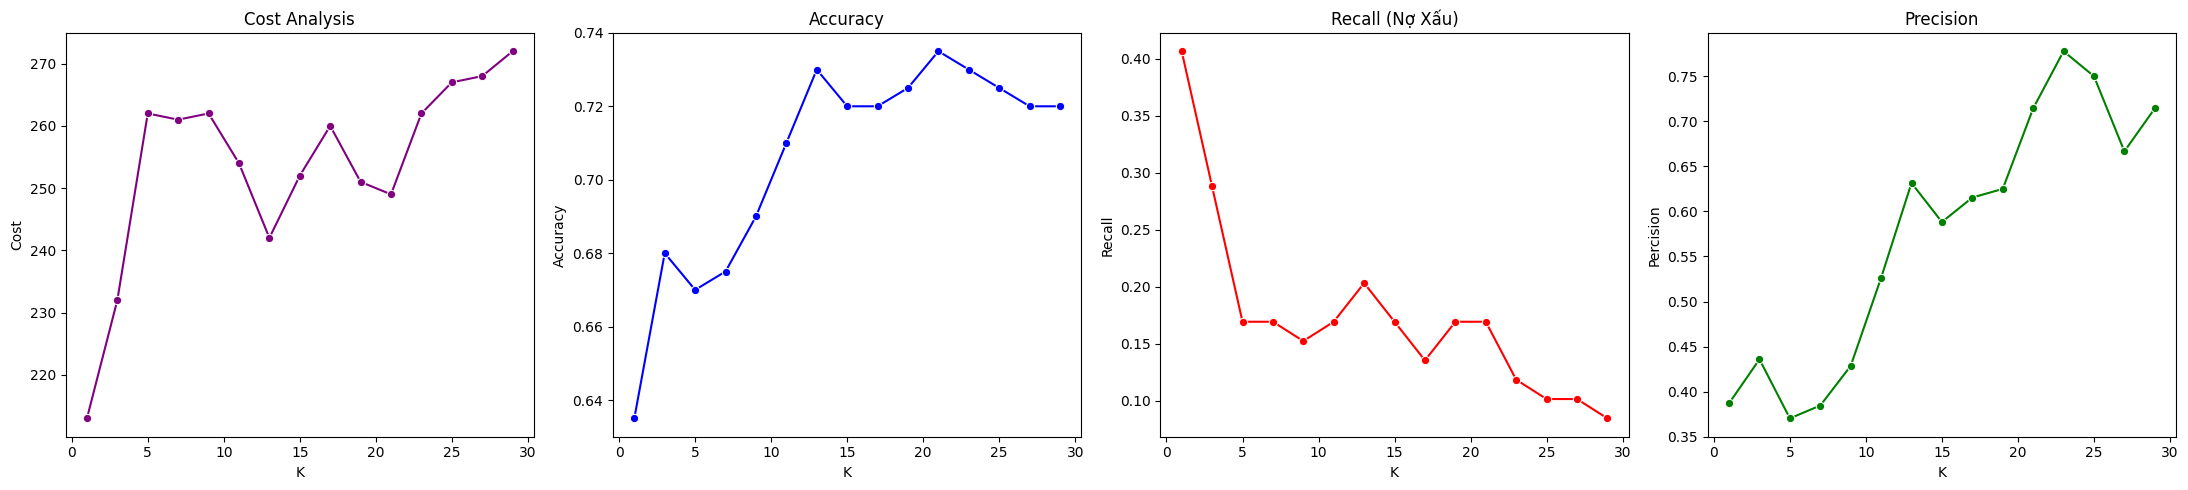

Max_Recall 0.41
Min_Cost 213


In [304]:
acc=[]
pcc=[]
rcc=[]
costt=[]

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='euclidean',p=2)
    model.fit(x_train,y_train)
    y_pred= model.predict(x_test)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())

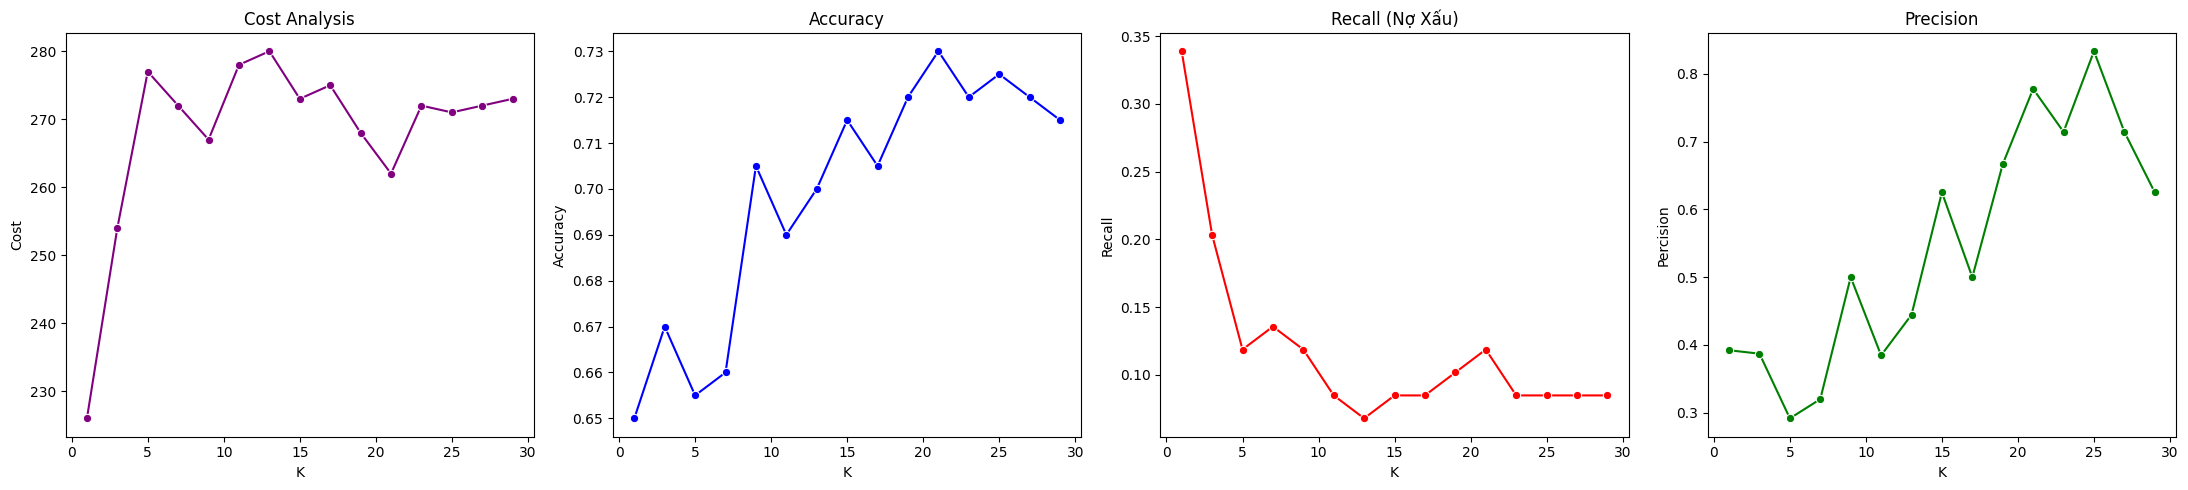

Max_Recall 0.34
Min_Cost 226


In [305]:
acc=[]
pcc=[]
rcc=[]
costt=[]

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='chebyshev',p=2)
    model.fit(x_train,y_train)
    y_pred= model.predict(x_test)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())


      A1    A2   A3    A4   A5   A6   A7   A8   A9   A10  ...  A15  A16  A17  \
29   1.0  60.0  3.0  68.0  1.0  5.0  3.0  4.0  4.0  63.0  ...  1.0  0.0  0.0   
535  3.0  21.0  4.0  23.0  1.0  2.0  1.0  1.0  3.0  33.0  ...  1.0  0.0  0.0   
695  4.0   6.0  2.0  12.0  3.0  3.0  3.0  4.0  2.0  50.0  ...  1.0  0.0  1.0   
557  4.0  21.0  0.0  50.0  5.0  3.0  2.0  4.0  2.0  29.0  ...  1.0  1.0  0.0   
836  4.0  12.0  2.0   9.0  5.0  3.0  2.0  2.0  3.0  21.0  ...  1.0  0.0  0.0   

     A18  A19  A20  A21  A22  A23  A24  
29   1.0  0.0  0.0  1.0  0.0  0.0  1.0  
535  1.0  0.0  1.0  0.0  0.0  0.0  1.0  
695  1.0  0.0  1.0  0.0  0.0  0.0  1.0  
557  1.0  0.0  0.0  1.0  0.0  0.0  1.0  
836  1.0  0.0  0.0  1.0  0.0  0.0  1.0  

[5 rows x 24 columns]


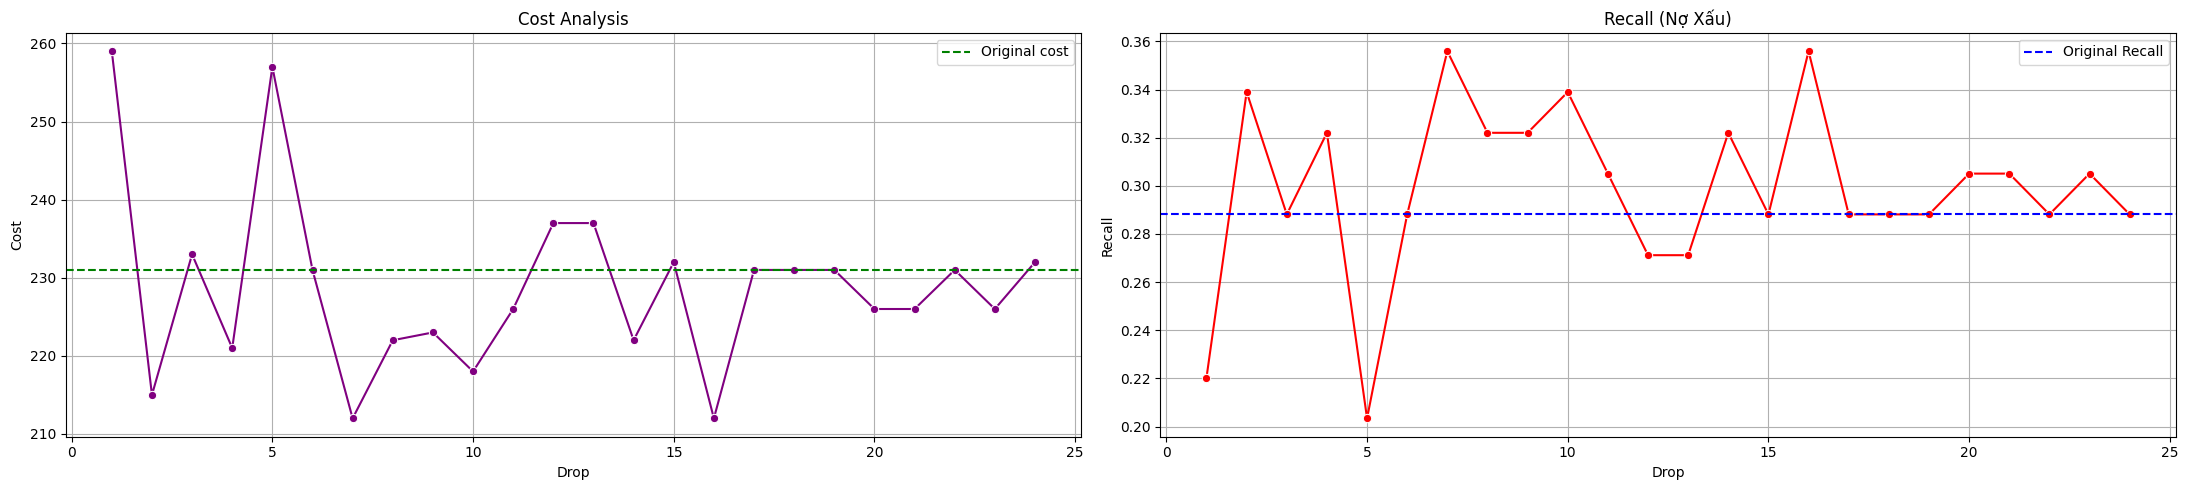

Max_Recall 0.36
Min_Cost 212


In [306]:
xtr=x_train
xts=x_test
rcc=[]
costt=[]
print(xtr.head())

model_ful=KNeighborsClassifier(n_neighbors=3,metric='manhattan',p=2)
model_ful.fit(x_train,y_train)
y_pred_ful=model_ful.predict(x_test)
cost_ful=cost(y_test,y_pred_ful)
rc_ful=recall_score(y_test,y_pred_ful,pos_label=0)

for i in range(1,25):
    xtr_tmp=xtr.copy()
    xts_tmp=xts.copy()
    x_train_drop=xtr_tmp.drop('A'+str(i), axis=1)
    x_test_drop=xts_tmp.drop('A'+str(i), axis=1)
    model=KNeighborsClassifier(n_neighbors=3,metric='manhattan',p=2)
    model.fit(x_train_drop,y_train)
    y_pred= model.predict(x_test_drop)

    tmp_=cost(y_test,y_pred)
    rc=recall_score(y_test,y_pred,pos_label=0)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'Drop': list(range(1,25)),
    'Cost': costt,
    'Recall': rcc,
})
fig, axes = plt.subplots(1, 2, figsize=(22, 5))
sns.lineplot(data=results, x='Drop', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].axhline(y=cost_ful, color='green', linestyle='--', label='Original cost')
axes[0].legend()
axes[0].set_title('Cost Analysis')
axes[0].grid()

sns.lineplot(data=results, x='Drop', y='Recall', ax=axes[1], marker='o', color='red')
axes[1].axhline(y=rc_ful, color='blue', linestyle='--', label='Original Recall')
axes[1].set_title('Recall (Nợ Xấu)')
axes[1].grid()


plt.tight_layout()
plt.legend()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())

In [307]:
xtr=x_train
xtr=xtr.reset_index(drop=True)
xts=x_test
xts=xts.reset_index(drop=True)
xts=xts.drop(['A'+str(i) for i in (2,4,7,8,9,10,11,14,16,20,21,23)],axis=1)
xtr=xtr.drop(['A'+str(i) for i in (2,4,7,8,9,10,11,14,16,20,21,23)],axis=1)

rcc=[]
costt=[]
print(xtr.head())
model_ful=KNeighborsClassifier(n_neighbors=3,metric='manhattan',p=2)
model_ful.fit(xtr,y_train)
y_pred_ful=model_ful.predict(xts)
cost_ful=cost(y_test,y_pred_ful)
rc_ful=recall_score(y_test,y_pred_ful,pos_label=0)
print("Max_Recall",f"{rc_ful:0.2f}")
print("Min_Cost",cost_ful)


    A1   A3   A5   A6  A12  A13  A15  A17  A18  A19  A22  A24
0  1.0  3.0  1.0  5.0  2.0  1.0  1.0  0.0  1.0  0.0  0.0  1.0
1  3.0  4.0  1.0  2.0  1.0  1.0  1.0  0.0  1.0  0.0  0.0  1.0
2  4.0  2.0  3.0  3.0  1.0  1.0  1.0  1.0  1.0  0.0  0.0  1.0
3  4.0  0.0  5.0  3.0  2.0  1.0  1.0  0.0  1.0  0.0  0.0  1.0
4  4.0  2.0  5.0  3.0  1.0  1.0  1.0  0.0  1.0  0.0  0.0  1.0
Max_Recall 0.46
Min_Cost 188


In [308]:
xtr=x_train
xtr=xtr.reset_index(drop=True)
xts=x_test
xts=xts.reset_index(drop=True)
#xts=xts.drop(['A'+str(i) for i in (2,4,7,8,9,10,11,14,16,20,21,23)],axis=1)
#xtr=xtr.drop(['A'+str(i) for i in (2,4,7,8,9,10,11,14,16,20,21,23)],axis=1)

cols = ['A'+str(i) for i in (1,5)]

xts = xts[cols]
xtr = xtr[cols]

rcc=[]
costt=[]
print(xtr.head())
model_ful=KNeighborsClassifier(n_neighbors=3,metric='manhattan',p=2)
model_ful.fit(xtr,y_train)
y_pred_ful=model_ful.predict(xts)
cost_ful=cost(y_test,y_pred_ful)
rc_ful=recall_score(y_test,y_pred_ful,pos_label=0)
print("Max_Recall",f"{rc_ful:0.2f}")
print("Min_Cost",cost_ful)


    A1   A5
0  1.0  1.0
1  3.0  1.0
2  4.0  3.0
3  4.0  5.0
4  4.0  5.0
Max_Recall 0.56
Min_Cost 164


    A1   A5
0  1.0  1.0
1  3.0  1.0
2  4.0  3.0
3  4.0  5.0
4  4.0  5.0


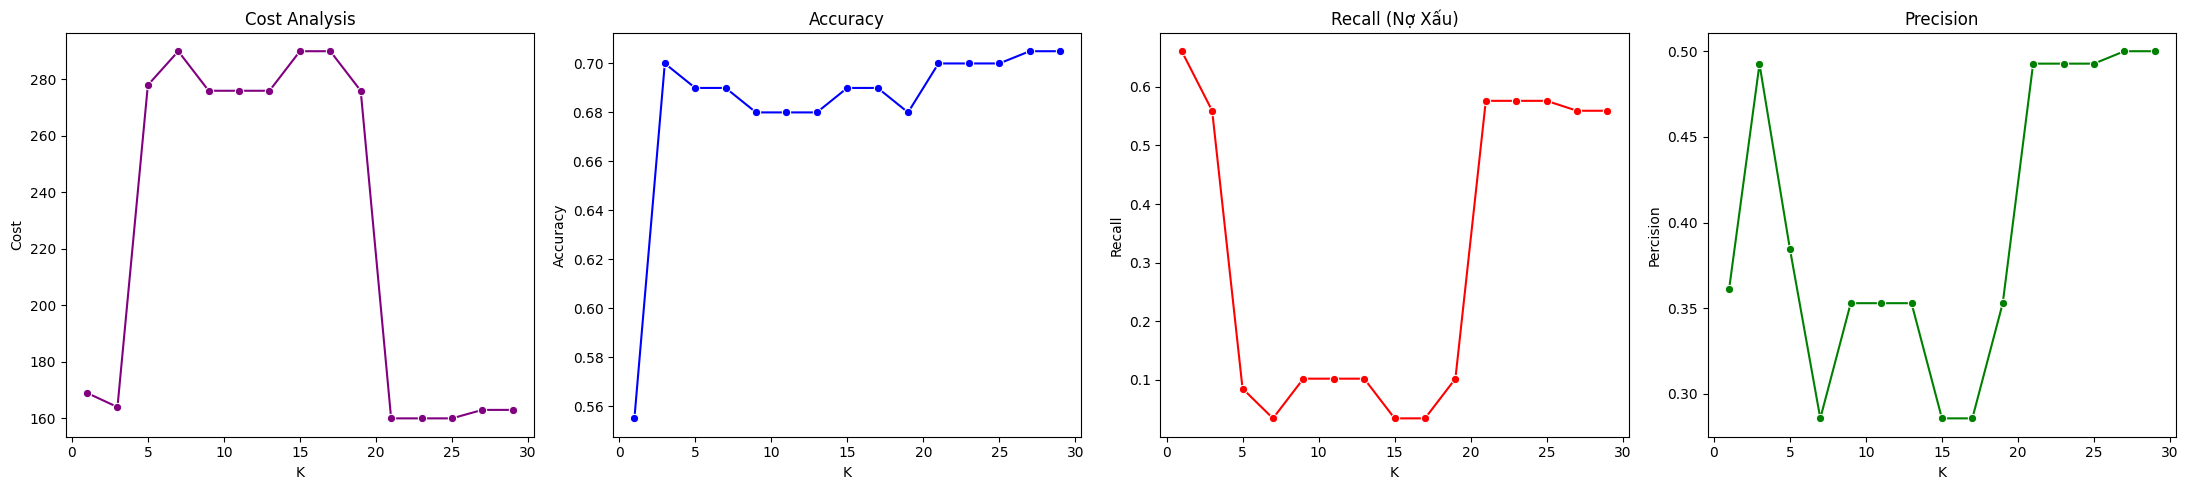

Max_Recall 0.66
Min_Cost 160


In [310]:
acc=[]
pcc=[]
rcc=[]
costt=[]

print(xtr.head())

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='manhattan',p=1)
    model.fit(xtr,y_train)
    y_pred= model.predict(xts)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())

    A1   A5
0  1.0  1.0
1  3.0  1.0
2  4.0  3.0
3  4.0  5.0
4  4.0  5.0


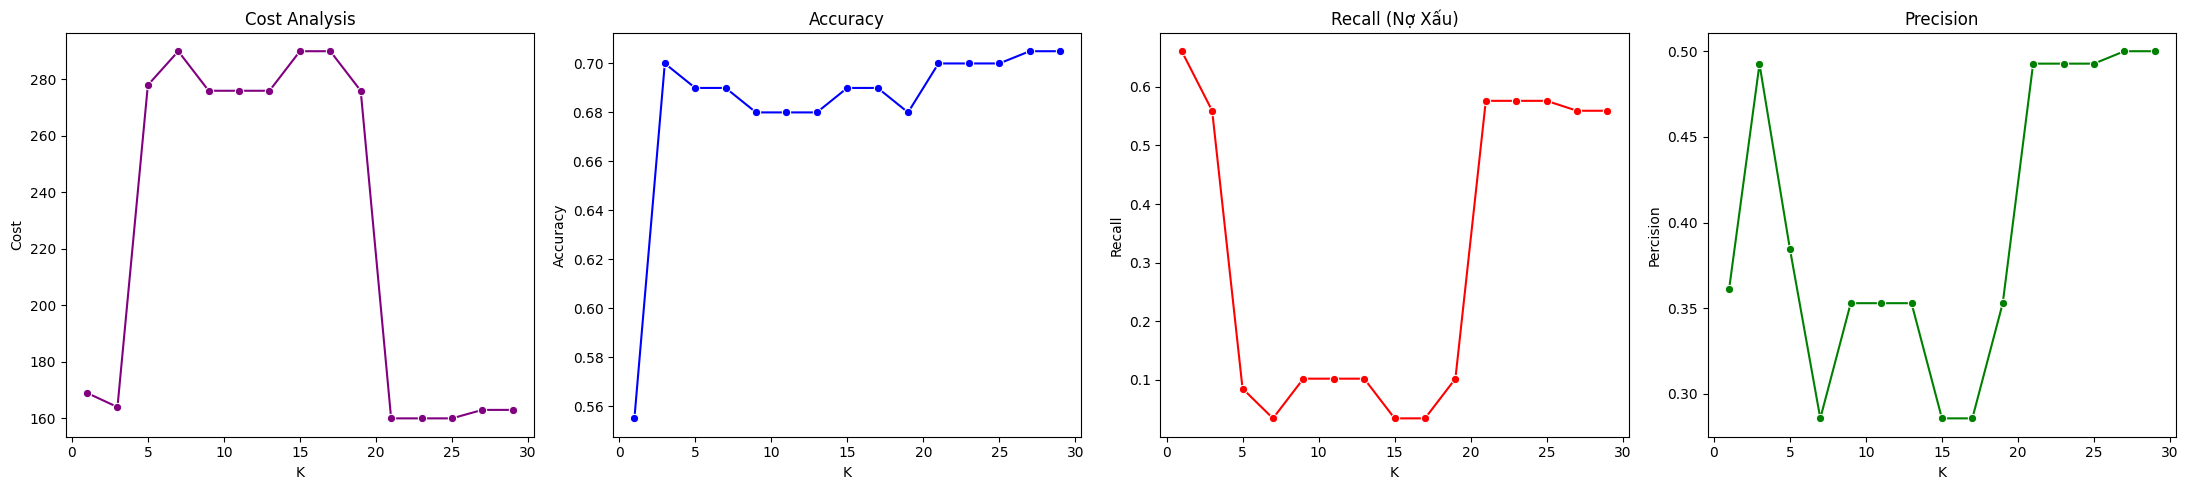

Max_Recall 0.66
Min_Cost 160


In [312]:
acc=[]
pcc=[]
rcc=[]
costt=[]

print(xtr.head())

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='minkowski',p=2)
    model.fit(xtr,y_train)
    y_pred= model.predict(xts)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())

    A1   A5
0  1.0  1.0
1  3.0  1.0
2  4.0  3.0
3  4.0  5.0
4  4.0  5.0


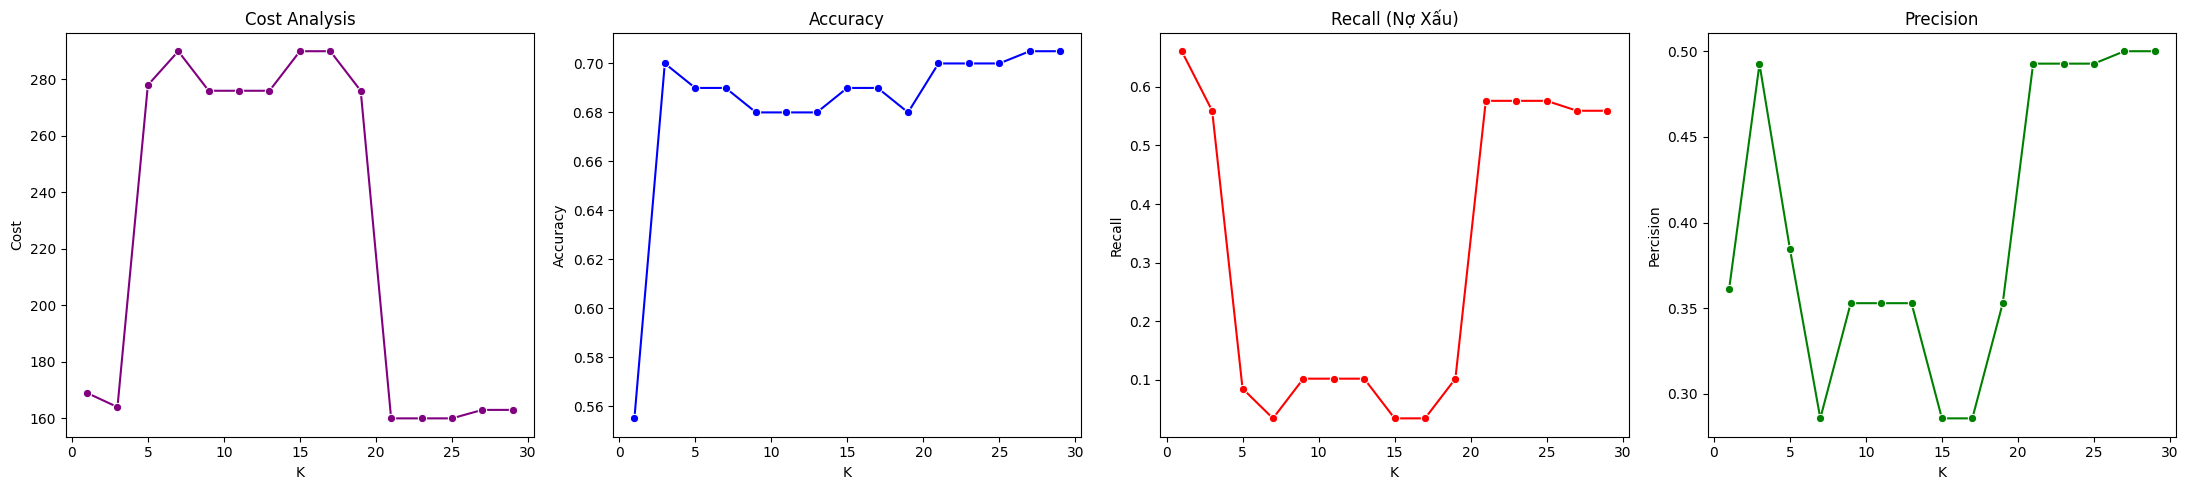

Max_Recall 0.66
Min_Cost 160


In [313]:
acc=[]
pcc=[]
rcc=[]
costt=[]

print(xtr.head())

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='euclidean',p=2)
    model.fit(xtr,y_train)
    y_pred= model.predict(xts)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())

    A1   A5
0  1.0  1.0
1  3.0  1.0
2  4.0  3.0
3  4.0  5.0
4  4.0  5.0


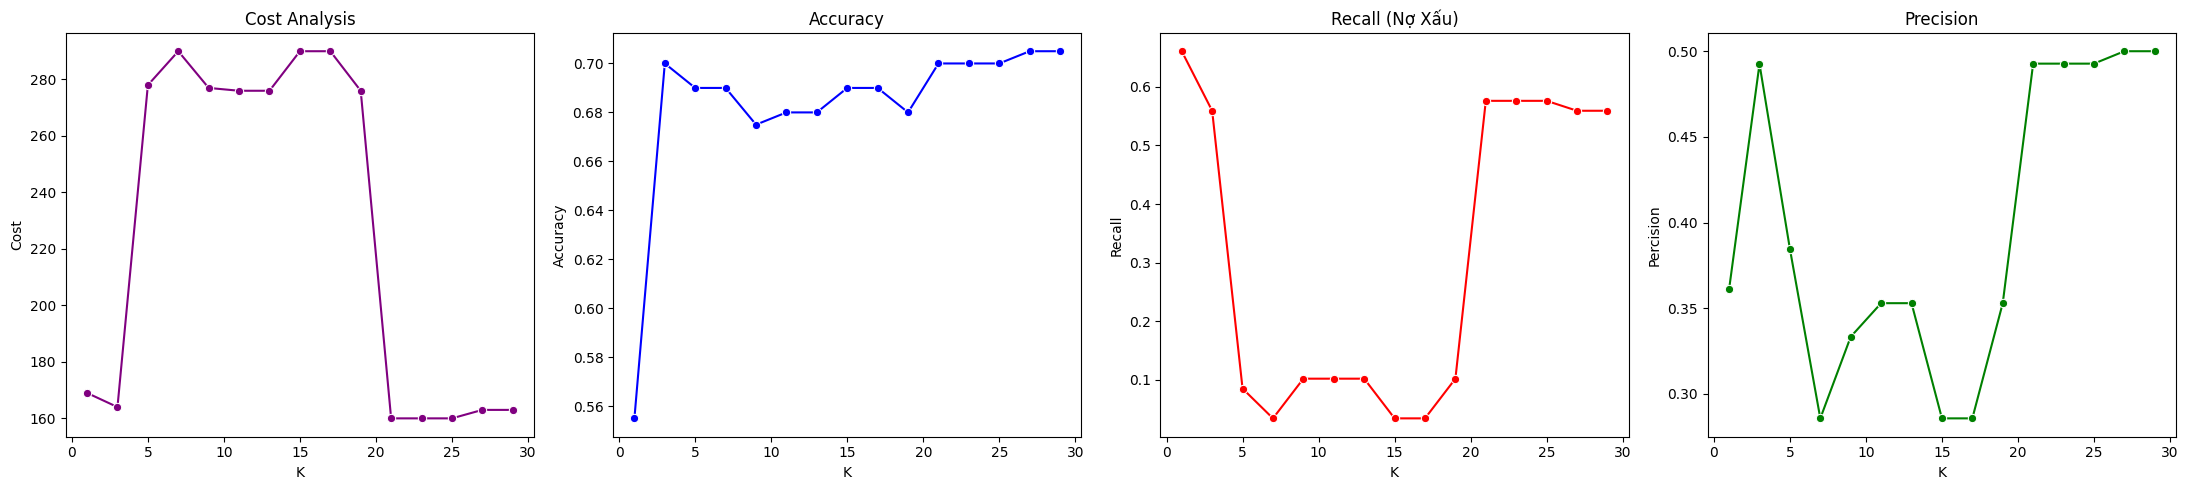

Max_Recall 0.66
Min_Cost 160


In [314]:
acc=[]
pcc=[]
rcc=[]
costt=[]

print(xtr.head())

for i in range(1,31,2):
    model=KNeighborsClassifier(n_neighbors=i,metric='chebyshev',p=2)
    model.fit(xtr,y_train)
    y_pred= model.predict(xts)

    tmp_=cost(y_test,y_pred)
   
    ac=accuracy_score(y_test,y_pred)
    pc=precision_score(y_test,y_pred,pos_label=0)
    rc=recall_score(y_test,y_pred,pos_label=0)
    acc.append(ac)
    pcc.append(pc)
    rcc.append(rc)
    costt.append(tmp_)
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'Cost': costt,
    'Accuracy': acc,
    'Recall': rcc,
    'Percision':pcc
})
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='Cost', ax=axes[0], marker='o', color='purple')
axes[0].set_title('Cost Analysis')

# Vẽ đồ thị 2: Accuracy
sns.lineplot(data=results, x='K', y='Accuracy', ax=axes[1], marker='o', color='blue')
axes[1].set_title('Accuracy')

# Vẽ đồ thị 3: Recall (Quan trọng nhất)
sns.lineplot(data=results, x='K', y='Recall', ax=axes[2], marker='o', color='red')
axes[2].set_title('Recall (Nợ Xấu)')

# Vẽ đồ thị 4: Precision
sns.lineplot(data=results, x='K', y='Percision', ax=axes[3], marker='o', color='green')
axes[3].set_title('Precision')

plt.tight_layout()
plt.show()
print("Max_Recall",f"{results['Recall'].max():0.2f}")
print("Min_Cost",results['Cost'].min())